In [5]:
from pathlib import Path
import sys
 
project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent
 
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
 
 
import sklearn as sk
import numpy as np
import polars as pl
import cvxopt
from src.ml.features import get_labeled_features
from cvxopt import matrix

In [19]:
Xdata = get_labeled_features('../../../data/processed/labeling_sample.csv')
Xdata.describe()

statistic,user_id,screen_name,name,followers_count,friends_count,listed_count,favourites_count,statuses_count,verified,default_profile,default_profile_image,created_at,last_tweet_at,first_seen_at,last_seen_at,profile_url,description,tweet_count,urls_per_tweet,hashtags_per_tweet,mentions_per_tweet,retweet_rate,reply_rate,unique_sources,bot_source_ratio,followers_friends_ratio,reputation,favourites_per_status,listed_per_follower,account_age_days,days_since_last_tweet,observation_span_days,tweet_frequency,tweets_per_day_in_dataset,description_length,has_description,has_url,has_location,screen_name_length,screen_name_has_digits,label
str,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",420.0,"""420""","""420""",420.0,420.0,420.0,420.0,420.0,420.0,420.0,420.0,"""420""","""420""","""420""","""420""","""122""","""355""",420.0,420.0,420.0,420.0,420.0,420.0,420.0,420.0,419.0,420.0,420.0,419.0,420.0,420.0,420.0,420.0,420.0,420.0,420.0,420.0,420.0,420.0,420.0,420.0
"""null_count""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""298""","""65""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",2.6313e17,null,null,5196.045238,1026.330952,34.640476,8805.935714,19065.221429,0.021429,0.588095,0.0,"""2013-10-22 20:07:02.754761""","""2018-06-16 05:53:13.933333""","""2018-06-15 15:21:48.807143""","""2018-06-16 05:53:13.933333""",null,null,2.997619,0.529609,1.605359,0.647562,0.450282,0.018262,1.071429,0.002381,44.79448,0.4501,1.387787,0.023633,1697.721429,0.616667,0.435714,0.071296,2.303571,69.619048,0.845238,0.290476,0.702381,11.002381,0.380952,0.171429
"""std""",4.1059e17,null,null,57782.513882,2727.6186,219.023297,18944.554625,41177.432631,null,null,null,null,null,null,null,null,null,4.967916,0.432737,1.435883,0.681988,0.444656,0.118165,0.292537,0.048795,625.400382,0.23705,4.022344,0.075789,1099.531765,0.798691,0.847943,0.701183,3.30621,54.172337,0.362109,0.454524,0.457756,2.694907,0.4862,0.377333
"""min""",1.5356678e7,"""0xnaomix0""","""#JeSuisProjectMaven""",0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,"""2008-07-08 18:49:55""","""2018-06-14 03:25:51""","""2018-06-14 02:38:24""","""2018-06-14 03:25:51""","""http://DanSpace77.com""",""""" Live for nothing or Die for …",1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.007853,0.0,0.0,0.0,0.0,0.0,0.0,0.000281,0.666667,0.0,0.0,0.0,0.0,5.0,0.0,0.0
"""25%""",2.59856581e8,null,null,103.0,167.0,0.0,394.0,1349.0,null,null,null,"""2011-03-02 18:52:27""","""2018-06-15 12:32:07""","""2018-06-14 15:46:42""","""2018-06-15 12:32:07""",null,null,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.374603,0.267504,0.138869,0.0,700.0,0.0,0.0,0.000563,1.0,24.0,1.0,0.0,0.0,9.0,0.0,0.0
"""50%""",1.6617e9,null,null,390.0,381.0,2.0,2128.0,7827.0,null,null,null,"""2013-08-11 05:53:23""","""2018-06-16 12:11:01""","""2018-06-15 15:25:59""","""2018-06-16 12:11:01""",null,null,1.0,0.5,1.2,0.666667,0.416667,0.0,1.0,0.0,0.857868,0.460501,0.499061,0.005634,1776.0,0.0,0.0,0.001247,1.0,61.0,1.0,0.0,1.0,11.0,0.0,0.0
"""75%""",7.5420e17,null,null,996.0,809.0,13.0,8925.0,20377.0,null,null,null,"""2016-07-16 06:38:55""","""2018-06-17 02:18:53""","""2018-06-16 13:22:50""","""2018-06-17 02:18:53""",null,null,3.0,1.0,2.0,1.0,1.0,0.0,1.0,0.0,1.476584,0.593112,1.2,0.019685,2663.0,1.0,0.0,0.003715,2.0,119.0,1.0,1.0,1.0,13.0,1.0,0.0
"""max""",1.0082e18,"""zavier_pk""","""🛸""",1.144084e6,33103.0,4064.0,202888.0,579655.0,1.0,1.0,0.0,"""2018-06-17 01:05:39""","""2018-06-17 16:54:14""","""2018-06-17 16:54:14""","""2018-06-17 16:54:14""","""https://youtu.be/tPEUnZaIc0I""","""🦀 1% Tweets Serios, 99% Drama,…",51.0,1.0,11.0,6.2,1.0,1.0,4.0,1.0,11941.0,0.999833,63.430657,0.886792,3630.0,2.0,3.0,12.0,51.0,167.0,1.0,1.0,1.0,15.0,1.0,1.0


C:\Users\Rodri\AppData\Local\Temp\ipykernel_17088\2653173486.py:10: RuntimeWarning: divide by zero encountered in log
  plt.scatter(np.log(Xdata[col0].to_numpy()), np.log(Xdata[col1].to_numpy()),


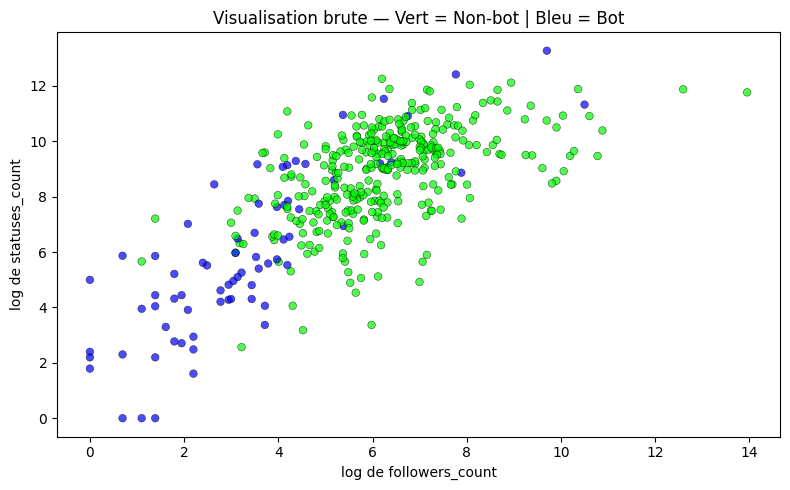

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Deux features numériques représentatives pour une première visualisation
col0, col1 = "followers_count", "statuses_count"

point_colors = np.where(Xdata["label"].to_numpy() == 1, "#0000FF", "#00FF00")

plt.figure(figsize=(8, 5))
plt.scatter(np.log(Xdata[col0].to_numpy()), np.log(Xdata[col1].to_numpy()),
            c=point_colors, edgecolors='k', linewidths=0.4, s=30, alpha=0.7)
plt.xlabel(f'log de {col0}')
plt.ylabel(f'log de {col1}')
plt.title("Visualisation brute — Vert = Non-bot | Bleu = Bot")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

solver = cvxopt.solvers.qp

# Colonnes à exclure : identifiants, texte libre, timestamps, label
DROP_COLS = {
    "user_id", "label",
    "screen_name", "name", "profile_url", "description",
    "created_at", "last_tweet_at", "first_seen_at", "last_seen_at",
}
feature_cols = [c for c in Xdata.columns if c not in DROP_COLS]

# Cast en Float64 dans Polars pour gérer les booléens (verified, default_profile…)
X_raw = Xdata.select([pl.col(c).cast(pl.Float64) for c in feature_cols]).to_numpy()

# Les features de tweets sont null pour les users sans tweets → on remplace par 0
X_raw = np.nan_to_num(X_raw, nan=0.0)

y = (2 * Xdata["label"] - 1).to_numpy().astype(float)

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# Split stratifié avant toute modélisation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

n, p = X_train.shape
print(f"Features utilisées : {p}")
print(f"  {feature_cols}")
print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"Bots train : {(y_train==1).sum()}/{len(y_train)} | Bots test : {(y_test==1).sum()}/{len(y_test)}")

# Matrices cvxopt (hard-margin pédagogique) — sur X_train
G_np = -1.0 * np.column_stack((np.diag(y_train) @ X_train, y_train))
q_np = np.zeros(p + 1)
h_np = -1.0 * np.ones(n)
P_np = np.zeros((p + 1, p + 1))
P_np[:p, :p] = np.identity(p)

P = matrix(P_np)
q = matrix(q_np)
G = matrix(G_np)
h = matrix(h_np)

Features utilisées : 31
  ['followers_count', 'friends_count', 'listed_count', 'favourites_count', 'statuses_count', 'verified', 'default_profile', 'default_profile_image', 'tweet_count', 'urls_per_tweet', 'hashtags_per_tweet', 'mentions_per_tweet', 'retweet_rate', 'reply_rate', 'unique_sources', 'bot_source_ratio', 'followers_friends_ratio', 'reputation', 'favourites_per_status', 'listed_per_follower', 'account_age_days', 'days_since_last_tweet', 'observation_span_days', 'tweet_frequency', 'tweets_per_day_in_dataset', 'description_length', 'has_description', 'has_url', 'has_location', 'screen_name_length', 'screen_name_has_digits']
Train : (336, 31) | Test : (84, 31)
Bots train : 58/336 | Bots test : 14/84


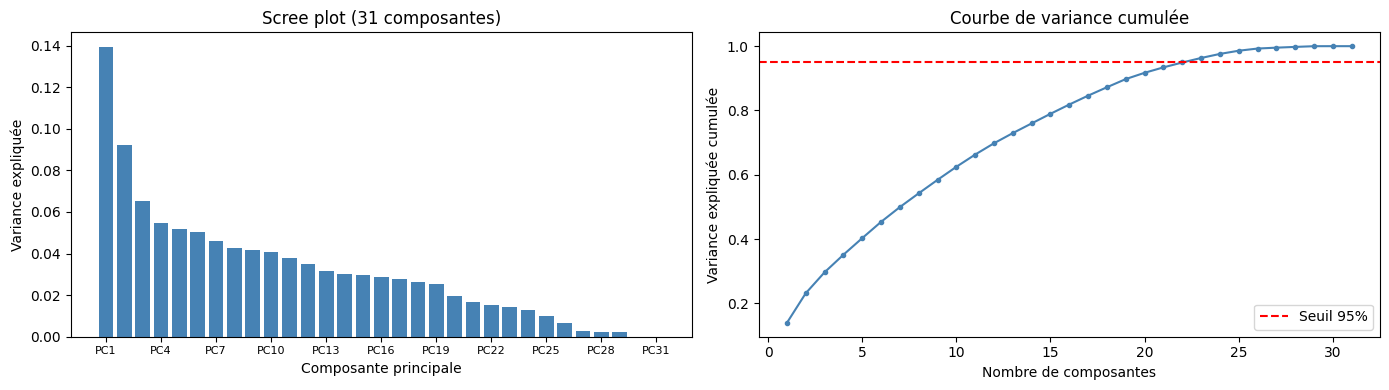

Composantes retenues : 23/31 (≥ 95% de variance)

X_train_pca : (336, 23) | X_test_pca : (84, 23)
Le SVM ci-dessous sera entraîné sur ces 23 composantes.

── Principales features par composante ACP ──
  PC1 (13.9%) : description_length (0.35), retweet_rate (0.35), has_description (0.33), account_age_days (0.32)
  PC2 (9.2%) : observation_span_days (0.48), tweet_count (0.47), days_since_last_tweet (0.33), tweets_per_day_in_dataset (0.32)
  PC3 (6.5%) : mentions_per_tweet (0.34), retweet_rate (0.31), has_url (0.29), friends_count (0.29)
  PC4 (5.5%) : bot_source_ratio (0.74), unique_sources (0.26), hashtags_per_tweet (0.23), has_url (0.19)
  PC5 (5.2%) : favourites_per_status (0.60), bot_source_ratio (0.39), screen_name_has_digits (0.38), hashtags_per_tweet (0.23)
  PC6 (5.1%) : favourites_per_status (0.49), description_length (0.31), reply_rate (0.28), unique_sources (0.28)
  PC7 (4.6%) : reply_rate (0.50), urls_per_tweet (0.40), mentions_per_tweet (0.37), account_age_days (0.35)
  PC8 

In [ ]:
# 1. Matrice de covariance empirique — calculée sur X_train uniquement
V = X_train.T @ X_train / X_train.shape[0]

# 2. Diagonalisation : valeurs propres λ et vecteurs propres u
eigenvalues, eigenvectors = np.linalg.eigh(V)

# 3. Tri par ordre décroissant (eigh retourne en ordre croissant)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# 4. Variance expliquée par composante
explained_ratio = eigenvalues / eigenvalues.sum()
cumvar = np.cumsum(explained_ratio)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(1, p + 1), explained_ratio, color='steelblue')
axes[0].set_xlabel("Composante principale")
axes[0].set_ylabel("Variance expliquée")
axes[0].set_title(f"Scree plot ({p} composantes)")
step = max(1, p // 10)
axes[0].set_xticks(range(1, p + 1, step))
axes[0].set_xticklabels([f"PC{i}" for i in range(1, p + 1, step)], fontsize=8)

axes[1].plot(range(1, p + 1), cumvar, marker='.', color='steelblue')
axes[1].axhline(0.95, color='red', linestyle='--', label='Seuil 95%')
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("Variance expliquée cumulée")
axes[1].set_title("Courbe de variance cumulée")
axes[1].legend()

plt.tight_layout()
plt.show()

# 5. Sélection automatique du nombre de composantes (seuil 95%)
n_components = int(np.argmax(cumvar >= 0.95)) + 1
print(f"Composantes retenues : {n_components}/{p} (≥ 95% de variance)")
print()

# 6. Matrice de projection W : colonnes = vecteurs propres retenus
W = eigenvectors[:, :n_components]   # shape (p, n_components)

X_train_pca = X_train @ W
X_test_pca  = X_test  @ W

print(f"X_train_pca : {X_train_pca.shape} | X_test_pca : {X_test_pca.shape}")
print(f"Le SVM ci-dessous sera entraîné sur ces {n_components} composantes.\n")

# 7. Analyse des features : top contributeurs pour chaque composante retenue
feature_names = np.array(feature_cols)
print("── Principales features par composante ACP ──")
TOP_K = 4
for i in range(n_components):
    loadings = np.abs(eigenvectors[:, i])
    top_idx  = np.argsort(loadings)[::-1][:TOP_K]
    top_feats = ", ".join(
        f"{feature_names[j]} ({loadings[j]:.2f})" for j in top_idx
    )
    print(f"  PC{i+1} ({explained_ratio[i]:.1%}) : {top_feats}")

     pcost       dcost       gap    pres   dres
 0:  2.0771e-01  2.4342e+02  2e+03  3e+00  6e+02
 1:  8.9342e-01  6.5021e+01  1e+03  2e+00  5e+02
 2:  2.2646e+00  3.1263e+02  1e+03  2e+00  3e+02
 3:  4.8241e+00  1.5192e+03  1e+03  1e+00  3e+02
 4:  1.2010e+01  3.4029e+03  1e+03  1e+00  3e+02
 5:  2.3685e+01  8.0349e+03  2e+03  1e+00  2e+02
 6:  1.3433e+01  2.2333e+04  4e+03  1e+00  2e+02
 7:  1.0904e+01  2.7319e+04  4e+03  1e+00  2e+02
 8:  1.0814e+00  8.5417e+04  9e+03  1e+00  2e+02
 9:  9.2108e-01  4.3632e+05  3e+04  1e+00  2e+02
10:  9.2669e-01  1.4018e+06  8e+04  1e+00  2e+02
11:  9.3195e-01  8.1563e+06  3e+05  1e+00  2e+02
12:  9.3414e-01  3.9174e+07  1e+06  1e+00  2e+02
13:  9.3704e-01  2.5600e+08  7e+06  1e+00  2e+02
14:  9.4431e-01  4.3554e+09  7e+07  1e+00  2e+02
15:  9.5459e-01  2.4615e+11  5e+08  1e+00  2e+02
16:  9.5778e-01  1.1283e+14  8e+09  1e+00  2e+02
Terminated (singular KKT matrix).
status : unknown
beta    : [ 0.     0.     0.     0.     0.    -0.602 -0.     0.     

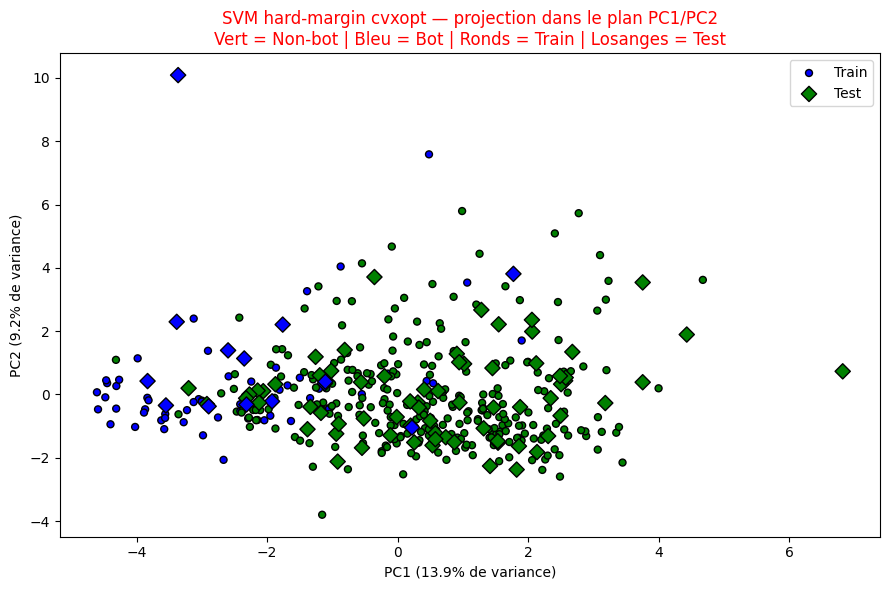

In [ ]:
sol = solver(P, q, G, h)

x_sol = np.array(sol["x"]).reshape(-1)   # x_sol = (beta, beta0)
beta  = x_sol[:p]
beta0 = x_sol[p]

print("status :", sol["status"])
print("beta    :", np.round(beta, 3))
print("beta0   :", round(beta0, 4))

# --- Visualisation dans l'espace ACP (PC1 vs PC2) ---
# La frontière beta·x + beta0 = 0 dans ℝᵖ se projette dans le plan PC1/PC2 :
#   x = W_2d @ x_pca  →  beta·x ≈ (W_2d^T @ beta) · x_pca
# Ce vecteur de 2 coordonnées donne la normale à la droite de séparation en 2D.
W_2d     = W[:, :2]
beta_2d  = W_2d.T @ beta

fig, ax = plt.subplots(figsize=(9, 6))

colors_tr = np.where(y_train == 1, "blue", "green")
ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
           c=colors_tr, edgecolors='k', s=25, zorder=2, label='Train')

colors_te = np.where(y_test == 1, "blue", "green")
ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1],
           c=colors_te, edgecolors='k', s=60, marker='D', zorder=2, label='Test')

if sol["status"] == "optimal" and abs(beta_2d[1]) > 1e-8:
    x1_vals = np.linspace(X_train_pca[:, 0].min() - 0.5,
                          X_train_pca[:, 0].max() + 0.5, 300)
    # Séparateur :  beta_2d[0]*x1 + beta_2d[1]*x2 + beta0 = 0
    ax.plot(x1_vals, -(beta_2d[0]*x1_vals + beta0     ) / beta_2d[1],
            color="red",   linewidth=2, label="Séparateur (f=0)")
    ax.plot(x1_vals, -(beta_2d[0]*x1_vals + beta0 - 1 ) / beta_2d[1],
            color="black", linewidth=1, linestyle="--", label="Marges (f=±1)")
    ax.plot(x1_vals, -(beta_2d[0]*x1_vals + beta0 + 1 ) / beta_2d[1],
            color="black", linewidth=1, linestyle="--")
else:
    ax.set_title("⚠  Solveur non convergé — données non séparables linéairement",
                 color="red", fontsize=10)

ax.set_xlabel(f"PC1 ({explained_ratio[0]:.1%} de variance)")
ax.set_ylabel(f"PC2 ({explained_ratio[1]:.1%} de variance)")
ax.set_title("SVM hard-margin cvxopt — projection dans le plan PC1/PC2\nVert = Non-bot | Bleu = Bot | Ronds = Train | Losanges = Test")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
svm = sk.svm.SVC(C=5, kernel='rbf', class_weight='balanced')
print(svm)

SVC(C=5, class_weight='balanced')


In [13]:
svm.fit(X_train_pca, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",5
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [14]:
y_pred = svm.predict(X_test_pca)

In [15]:
err = 1.0 - sk.metrics.accuracy_score(y_test, y_pred)
print(f"Taux d'erreur : {err:.3f}")
err

Taux d'erreur : 0.107


0.1071428571428571

In [ ]:
print('beta0 (intercept) =', svm.intercept_)
print('Indices des vecteurs de support =', svm.support_)
print('Nombre de vecteurs de support par classe =', svm.n_support_)
print('|dual_coef_| max =', np.abs(svm.dual_coef_).max().round(4))

beta0 (intercept) = [-0.10855105]
Indices des vecteurs de support = [  6  16  18  27  30  39  45  46  48  50  52  59  60  67  68  71  77  78
  80  82  83  86  91  94  97 100 111 114 116 117 118 119 120 122 125 128
 133 135 139 145 159 160 163 177 181 188 194 200 203 208 209 211 212 213
 220 235 240 244 246 249 250 260 263 274 278 280 285 288 295 297 298 300
 311 312 323 328 333   0  23  32  34  35  65  66  73  92  99 113 121 126
 127 152 174 176 183 184 196 210 222 226 228 229 232 237 243 247 252 265
 289 304 310 313 331]
Nombre de vecteurs de support par classe = [77 36]
|dual_coef_| max = 9.6056


Train : 336 samples | Test : 84 samples
Bots dans le test : 14/84 (16.7%)

── Rapport de classification ──
              precision    recall  f1-score   support

Non-bot (-1)       0.94      0.93      0.94        70
    Bot (+1)       0.67      0.71      0.69        14

    accuracy                           0.89        84
   macro avg       0.80      0.82      0.81        84
weighted avg       0.90      0.89      0.89        84



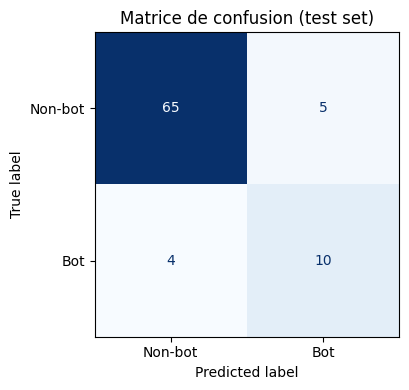

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(f"Train : {len(X_train_pca)} samples | Test : {len(X_test_pca)} samples")
print(f"Bots dans le test : {(y_test==1).sum()}/{len(y_test)} ({(y_test==1).mean():.1%})\n")

print("── Rapport de classification ──")
print(classification_report(y_test, y_pred, target_names=["Non-bot (-1)", "Bot (+1)"]))

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                              display_labels=["Non-bot", "Bot"])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Matrice de confusion (test set)")
plt.tight_layout()
plt.show()
